## Introdução

### Objetivo & Metodologia

Investigar fatores associados à **velocidade de ocorrência de registros de falhas no sistema de ar condicionado da frota de ônibus** do Rio de Janeiro durante a Operação Verão, utilizando técnicas de análise exploratória e análise de sobrevivência

Para isso, foram integradas bases de dados relacionadas à operação da frota municipal, incluindo informações de licenciamento dos veículos, registros operacionais e ocorrências relacionadas à fiscalização do funcionamento do sistema de climatização.

A unidade de análise adotada foi o veículo. Para cada ônibus, buscou-se identificar:

- O período em que o veículo esteve observado na base operacional;
- A ocorrência de registros relacionados a falhas ou inoperância do ar condicionado;
- Características estruturais e operacionais da frota, como idade do veículo, fabricante e informações de licenciamento.

A utilização da análise de sobrevivência se justifica porque nem todos os veículos apresentam registros durante o período analisado. Assim, alguns ônibus possuem o evento observado, enquanto outros permanecem sem registro até o final da janela de observação. Esse tipo de situação é chamado de censura e não pode ser tratado adequadamente por métodos estatísticos tradicionais focados apenas em classificação ou médias.

Dessa forma, a análise de sobrevivência permite modelar:

- o tempo até ocorrência do primeiro registro;
- diferenças entre grupos de veículos;
- possíveis fatores associados ao aumento ou redução do risco de ocorrência do evento.

Com isso, o trabalho busca compreender padrões relacionados às falhas de climatização da frota conjuntamente a um monitoramento da Operação Verão.

| Parte       | Papel                           |
| ----------- | ------------------------------- |
| Evento      | registro de ar quebrado ou inoperante |
| Tempo       | tempo até ocorrer o registro              |
| Unidade     | ônibus com ar condicionado      |
| Censura     | veículos que não foram registrados            |
| Covariáveis | idade, fabricante, lotação etc. |


### Visão Geral dos Dados

In [173]:
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [174]:
df_licenciamento = pd.read_csv("licenciamento.csv")
df_registros = pd.read_csv("sppo_registro_agente_verao.csv")
df_veiculo_dia = pd.read_csv("sppo_veiculo_dia.csv")

In [175]:
def resumo_dataframe(df):
    info = pd.DataFrame({
        "Coluna": df.columns,
        "Tipo de Dado": df.dtypes,
        "Valores Únicos": df.nunique(),
        "Valores Nulos": df.isnull().sum()
    })

    print(df.shape)
    return info

#### Tabela Licenciamento

Descrição Oficial no Data.Rio:

Tabela histórica de dados cadastrais dos veí­culos que operam o sistema de ônibus (BRT e SPPO), considerando tanto os licenciados no Sistema de Transporte Urbano (STU) quanto as solicitações válidas em andamento para ingresso no sistema

In [176]:
print("Head Dataframe Licenciamento:")
df_licenciamento.head(2)

Head Dataframe Licenciamento:


,data,modo,id_veiculo,ano_fabricacao,carroceria,data_ultima_vistoria,id_carroceria,id_chassi,id_fabricante_chassi,id_interno_carroceria,...,tecnologia,quantidade_lotacao_pe,quantidade_lotacao_sentado,tipo_combustivel,tipo_veiculo,status,data_inicio_vinculo,ano_ultima_vistoria_atualizado,datetime_ultima_atualizacao,versao
0,2023-07-09,ONIBUS,B11563,2018,INDUSCAR - CAIO,2022-06-29,62,258,35,62,...,BASICO,39,38,DIESEL,51 ONIBUS BS URB C/AR C/E 2CAT,Licenciado,NaN,2022.0,2025-01-17 07:09:48.824713,1069dba3a1bee76d11686023ac8dcd2a453b47e7
1,2023-10-28,ONIBUS,D17176,2015,INDUSCAR - CAIO,NaN,62,258,35,62,...,NaN,38,38,DIESEL,51 ONIBUS BS URB C/AR C/E 2CAT,Licenciado,NaN,NaN,2025-07-08 19:51:38.157384,432fd8b43c8d00bd72b10115bcf6649a74371543


In [177]:
resumo_dataframe(df_licenciamento)

(222625, 28)


,Coluna,Tipo de Dado,Valores Únicos,Valores Nulos
data,data,object,682,0
modo,modo,object,1,0
id_veiculo,id_veiculo,object,6598,0
ano_fabricacao,ano_fabricacao,int64,17,0
carroceria,carroceria,object,18,0
data_ultima_vistoria,data_ultima_vistoria,object,1403,22513
id_carroceria,id_carroceria,int64,18,0
id_chassi,id_chassi,int64,35,0
id_fabricante_chassi,id_fabricante_chassi,int64,10,0
id_interno_carroceria,id_interno_carroceria,int64,18,0


#### Tabela Registro Agente Verão

Descrição Oficial Data.Rio:

Tabela de registros de ocorrências de ar inoperante em veí­culos do sistema de ônibus municipal (SPPO), referentes ao projeto Agentes de Verão (RESOLUÇÃO SMTR Nº 3.682/2024)

In [178]:
print("Head Dataframe Registro:")
df_registros.head(2)

Head Dataframe Registro:


,data,datetime_registro,id_registro,id_veiculo,servico,link_foto,validacao,datetime_captura,versao
0,2024-04-09,2024-04-09 19:01:04,K\xCB\x84\x0B\x5C\xD1L-u$\xAB\x8Fj\xF3\xA0\x90...,D17035,796,https://drive.google.com/open?id=1-TwajsIounr6...,True,2024-04-10 07:00:00,ee9ea4f58690d3745063cea45a13196a091e547a
1,2024-04-09,2024-04-09 16:23:59,\x07\x0F\xB90\xDD\x8B)\x0B\xF3\x18\xAFI\xAD)\x...,C44543,783,https://drive.google.com/open?id=1W1D5O2Ln5MJe...,True,2024-04-10 07:00:00,ee9ea4f58690d3745063cea45a13196a091e547a


In [179]:
resumo_dataframe(df_registros)

(392, 9)


,Coluna,Tipo de Dado,Valores Únicos,Valores Nulos
data,data,object,92,0
datetime_registro,datetime_registro,object,392,0
id_registro,id_registro,object,392,0
id_veiculo,id_veiculo,object,313,0
servico,servico,object,99,0
link_foto,link_foto,object,392,0
validacao,validacao,bool,1,0
datetime_captura,datetime_captura,object,80,0
versao,versao,object,61,0


#### Tabela Veiculo Dia

Descrição Oficial Data.Rio:

Tabela resumo dos veículos que operaram no SPPO e seus respectivos indicadores

In [180]:
print("Veiculos Dias:")
df_veiculo_dia.head(2)

Veiculos Dias:


,data,id_veiculo,indicadores,status,tecnologia,placa,data_licenciamento,data_infracao,datetime_ultima_atualizacao,versao
0,2023-03-01,A41190,"{""indicador_ar_condicionado"":true,""indicador_a...",Licenciado com ar e não autuado (023.II),NaN,NaN,NaN,NaN,2023-03-01 00:00:00,NaN
1,2024-07-29,A50052,"{""indicador_ar_condicionado"":true,""indicador_a...",Licenciado com ar e não autuado,NaN,NaN,NaN,NaN,2024-07-29 00:00:00,389645e94331a6482e15e038430440ff7db39778


In [181]:
resumo_dataframe(df_veiculo_dia)

(136939, 10)


,Coluna,Tipo de Dado,Valores Únicos,Valores Nulos
data,data,object,806,0
id_veiculo,id_veiculo,object,5225,0
indicadores,indicadores,object,52,0
status,status,object,12,0
tecnologia,tecnologia,object,4,122463
placa,placa,object,3829,122463
data_licenciamento,data_licenciamento,object,64,121381
data_infracao,data_infracao,object,63,121381
datetime_ultima_atualizacao,datetime_ultima_atualizacao,object,596,0
versao,versao,object,65,31537


## Tratamento de Dados

Nosso objetivo aqui é definir a janela de tempo do estudo e criar um dataframe limpo onde cada linha é um ônibus que possui ar condicionado, e com colunas como:
- ID do ônibus
- Indicadora se houve registro do ônibus durante a janela de estudo,
- Tempo que o ônibus esteve exposto a ser registrado
- Outras covariáveis como: Idade ônibus, carroceria, lotação máxima, etc.

### Tratamento das colunas de Data.

Para todas as colunas de data em formato str, vamos converter em datetime.

Além disso, vamos criar as seguintes colunas:
- Colunas com granularidade de dia, mês e ano.
- Coluna da idade do veículo a partir do ano fabricação e a data da observação.

In [182]:
def transformar_colunas_data(df):
    """
    Converte colunas iniciadas por 'data' ou 'date' para datetime
    e cria colunas auxiliares de ano/mês/dia.
    """

    df = df.copy()

    # Identifica colunas de data
    colunas_data = [
        col for col in df.columns
        if isinstance(col, str)
        and col.lower().startswith(("data", "date"))
    ]

    if not colunas_data:
        print("Nenhuma coluna de data encontrada.")
        return df

    # Cria estação do ano para coluna 'data'
    if "data" in df.columns:
        try:
            df["data"] = pd.to_datetime(
                df["data"],
                errors="coerce"
            )

            df[f"{"data"}_ano"] = df["data"].dt.year
            df[f"{"data"}_mes"] = df["data"].dt.month
            df[f"{"data"}_dia"] = df["data"].dt.day

        except Exception as e:
            print(f"Erro ao processar coluna: {e}")

    return df

df_licenciamento = transformar_colunas_data(df_licenciamento)
df_registros = transformar_colunas_data(df_registros)
df_veiculo_dia = transformar_colunas_data(df_veiculo_dia)

In [183]:
df_licenciamento["idade_veiculo"] = df_licenciamento["data_ano"] - df_licenciamento["ano_fabricacao"]

### Limpeza dos Dados

Para o modelo de Análise de Sobrevivência que vamos usar, consideramos apenas o _primeiro_ evento, então devemos remover registros em ônibus que não são o primeiro.

In [184]:
df_registros_unicos = df_registros.sort_values("data").drop_duplicates(subset="id_veiculo", keep="first")
print(f"Quantidade de registros não únicos de ônibus: {len(df_registros) - len(df_registros_unicos)}")

Quantidade de registros não únicos de ônibus: 79


Uma das primeiras coisas que devemos fazer em Análise de Sobrevivência é definir a janela de tempo/periodo do estudo

<Axes: ylabel='data'>

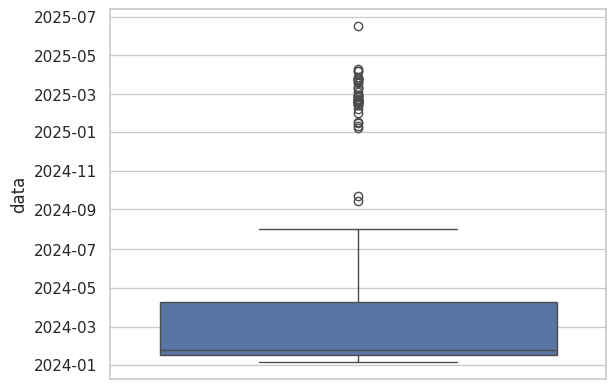

In [185]:
sns.boxplot(df_registros_unicos["data"])

Vemos que os registros estão concentrados em dois blocos de tempo, sendo o principal começando em 2024 e indo até o mês de agosto do mesmo ano, o segundo para janeiro a maio de 2025.

Há um período que não houve registros, se considerarmos a janela até a última observação, estariámos inflando a sobrevivência de vários ônibus. Portanto, vamos considerar a janela como o primeiro bloco temporal.

In [186]:
janela_estudo = ("2024-01-01", "2024-08-10")

df_registros_janela = df_registros_unicos[
    (df_registros_unicos["data"] >= janela_estudo[0]) &
    (df_registros_unicos["data"] <= janela_estudo[1])
]

df_veiculo_dia_janela = df_veiculo_dia[
    (df_veiculo_dia["data"] >= janela_estudo[0]) &
    (df_veiculo_dia["data"] <= janela_estudo[1])
]

df_licenciamento_janela = df_licenciamento[
    (df_licenciamento["data"] >= janela_estudo[0]) &
    (df_licenciamento["data"] <= janela_estudo[1])
]

Vamos começar a construir o dataframe principal a partir da tabela de licenciamento pois é a que possui o maior número de variáveis utilizadas. Devemos excluir as duplicadas temporais, e vamos manter as covariáveis como sendo as últimas observadas durante a janela.

In [187]:
df_frota = df_licenciamento_janela.sort_values('data').drop_duplicates(subset='id_veiculo', keep='last')
#Para cada ônibus pegamos as features mais atualizadas na janela de estudo

Vamos considerar que os ônibus que não possuem ar condicionado não podem ser registrados com ar inoperante.

In [188]:
#Filtrar apenas para ônibus com ar condicionado
df_frota = df_frota[df_frota["indicador_ar_condicionado"] == True]

# Cria mapeamento id_veiculo -> data
mapa_data = (
    df_registros_janela
    .set_index("id_veiculo")["data"]
)

# Coluna indicando presença
df_frota["possui_registro"] = (
    df_frota["id_veiculo"]
    .isin(df_registros_janela["id_veiculo"])
)

# Coluna com a data correspondente
df_frota["data_registro"] = (
    df_frota["id_veiculo"]
    .map(mapa_data)
)

df_frota["possui_registro"].value_counts()

,count
possui_registro,
False,3944
True,251


In [189]:
# Primeira e última aparição por veículo
datas_veiculo = (
    df_veiculo_dia_janela
    .groupby("id_veiculo")["data"]
    .agg(
        primeira_data_aparicao="min",
        ultima_data_aparicao="max"
    )
)

# Merge com df_frota
df_frota_t = df_frota.merge(
    datas_veiculo,
    on="id_veiculo",
    how="left"
)

#excluir valores faltantes em df_frota_t
print(f"Quantidade de registros com valores faltantes: {df_frota_t.isnull().sum().sum()}")
df_frota_t = df_frota_t.dropna(subset=["primeira_data_aparicao", "ultima_data_aparicao"])

#excluir casos onde a primeira data de aparição é maior ou igual à última data de aparição
print(f"Quantidade de registros com primeira data de aparição maior ou igual à última: {df_frota_t[df_frota_t['primeira_data_aparicao'] >= df_frota_t['ultima_data_aparicao']].shape[0]}")
df_frota_t = df_frota_t[df_frota_t["primeira_data_aparicao"] < df_frota_t["ultima_data_aparicao"]]

Quantidade de registros com valores faltantes: 5360
Quantidade de registros com primeira data de aparição maior ou igual à última: 60


In [190]:
import numpy as np

df_frota_t["tempo"] = np.where(
    df_frota_t["data_registro"].notna(),

    # Caso data_registro exista
    (
        df_frota_t["data_registro"]
        - df_frota_t["primeira_data_aparicao"]
    ).dt.days,

    # Caso contrário
    (
        df_frota_t["ultima_data_aparicao"]
        - df_frota_t["primeira_data_aparicao"]
    ).dt.days
)

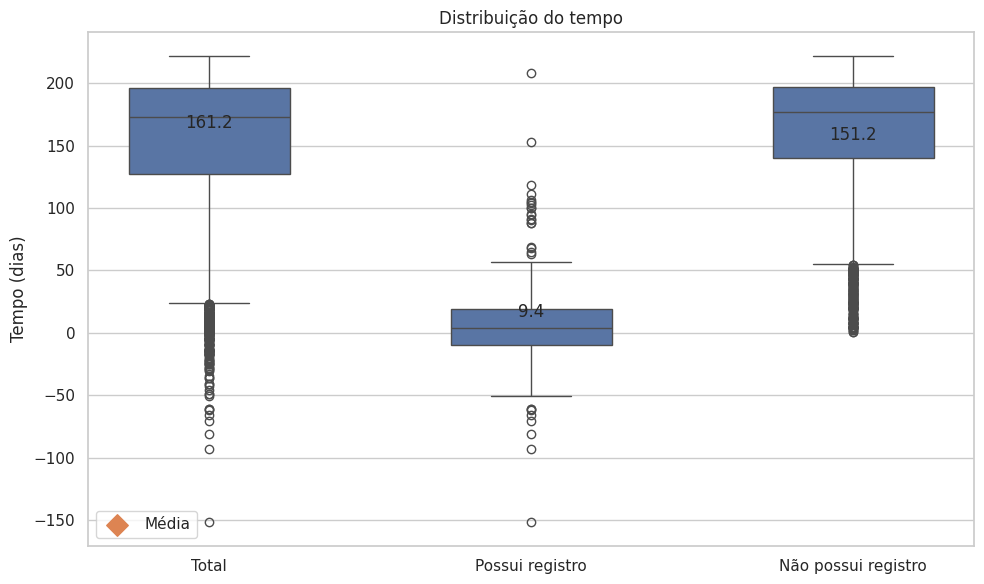

In [191]:
sns.set_theme(style="whitegrid")

# DataFrame auxiliar
df_plot = pd.concat([
    pd.DataFrame({
        "grupo": "Total",
        "tempo": df_frota_t["tempo"]
    }),

    pd.DataFrame({
        "grupo": "Possui registro",
        "tempo": df_frota_t.loc[
            df_frota_t["possui_registro"] == True,
            "tempo"
        ]
    }),

    pd.DataFrame({
        "grupo": "Não possui registro",
        "tempo": df_frota_t.loc[
            df_frota_t["possui_registro"] == False,
            "tempo"
        ]
    })
])

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df_plot,
    x="grupo",
    y="tempo",
    width=0.5
)

# Médias
medias = (
    df_plot
    .groupby("grupo")["tempo"]
    .mean()
)

# Pontos das médias
plt.scatter(
    x=range(len(medias)),
    y=medias.values,
    s=120,
    marker="D",
    label="Média"
)

# Texto das médias
for i, media in enumerate(medias.values):
    plt.text(
        i,
        media,
        f"{media:.1f}",
        ha="center",
        va="bottom"
    )

plt.title("Distribuição do tempo")
plt.xlabel("")
plt.ylabel("Tempo (dias)")

plt.legend()
plt.tight_layout()
plt.show()

Tempos negativos não deveriam existir e eles são quase metade dos registros. Isso indica que os ônibus tiverem ocorrência registradas em dias que o sistema eletrônico não esteve funcionando. Temos três opções a tomar:
Reconsiderar o período de exposição dos ônibus para começar no primeiro dia da janela de estudos
Desconsiderar esses ônibus que tiveram registros antes do período de exposição (censurados a esquerda)
A decisão "ótima" que pondera (de alguma forma) as duas opções anteriores

Vamos seguir pela segunda opção.

In [192]:
#Excluir tempos negativos
df_frota_t = df_frota_t[df_frota_t["tempo"] > 0]

### Outras covariáveis

A coluna de carroceria tem algumas categorias sujas que se referem a mesma marca, mas com digitação levemente diferente. Também precisamos fazer essa limpeza.

In [193]:
mapeamento = {
    "MARCOPOLO": "MARCOPOLO",
    "MARCOPOLO VIALE": "MARCOPOLO",
    "MARCOPOLO S/A.": "MARCOPOLO",
    "MARCOPOLO S.A.": "MARCOPOLO",
    "MARCOPOLO S.A": "MARCOPOLO",
    "MARCOLOPO S/A.": "MARCOPOLO",
    "MARCOPLO": "MARCOPOLO",
    "MARCOPLO S.A.": "MARCOPOLO",

    "INDUSCAR - CAIO": "CAIO",
    "INDUSCAR CAIO": "CAIO",
    "INDUSCAR": "CAIO",
    "CAIO": "CAIO",

    "NEOBUS - SAN MARINO": "NEOBUS",
    "SAN MARINO - NEOBUS": "NEOBUS",

    "COMIL": "COMIL",
    "BUSSCAR": "BUSSCAR",
    "MASCARELLO": "MASCARELLO"
}

df_frota_t["carroceria_padronizada"] = (
    df_frota_t["carroceria"]
    .replace(mapeamento)
)

Criar coluna com a soma das lotações em pé e sentado.

In [194]:
df_frota_t["lotacao_total"] = df_frota_t["quantidade_lotacao_pe"] + df_frota_t["quantidade_lotacao_sentado"]

### Dataframe Princial

Vamos criar o dataframe final apenas com as colunas que iremos utilizar.

In [195]:
variaveis_mantidas = [
    "id_veiculo", "indicador_elevador", "indicador_usb", "indicador_wifi",
    "tecnologia", "lotacao_total",
    "tipo_veiculo", "data_mes", "data_dia", "idade_veiculo",
    "possui_registro", "tempo", "carroceria_padronizada"
]

df_main = df_frota_t[variaveis_mantidas].copy()

resumo_dataframe(df_main)

(3660, 13)


,Coluna,Tipo de Dado,Valores Únicos,Valores Nulos
id_veiculo,id_veiculo,object,3660,0
indicador_elevador,indicador_elevador,bool,2,0
indicador_usb,indicador_usb,bool,2,0
indicador_wifi,indicador_wifi,bool,2,0
tecnologia,tecnologia,object,4,320
lotacao_total,lotacao_total,int64,39,0
tipo_veiculo,tipo_veiculo,object,9,0
data_mes,data_mes,int32,7,0
data_dia,data_dia,int32,31,0
idade_veiculo,idade_veiculo,int64,16,0


## Análise Exploratória de Dados

### Taxa global de Sobreviventes e Autuados

/tmp/ipykernel_22995/1058706681.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_22995/1058706681.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Não (Sobreviveu)', 'Sim (Registrado)'], fontsize=11)


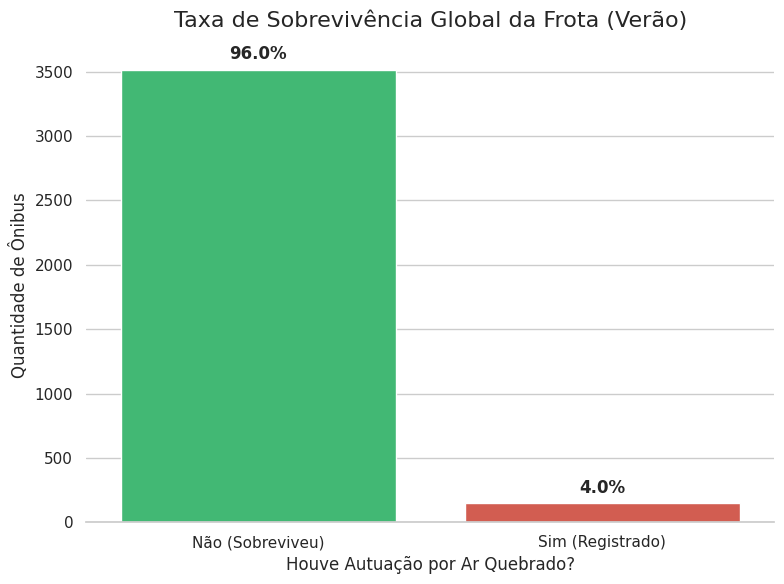

In [196]:
# Configurando o estilo geral dos gráficos para um visual mais limpo e profissional
sns.set_theme(style="whitegrid", palette="muted")

def plot_taxa_censura(df):
    plt.figure(figsize=(8, 6))

    # Criando o gráfico de barras para contar os True e False
    ax = sns.countplot(
        data=df,
        x='possui_registro',
        palette=['#2ecc71', '#e74c3c'], # Verde para quem sobreviveu (False), Vermelho pra quem falhou (True)
        order=[False, True]
    )

    # Adicionando título e rótulos
    plt.title('Taxa de Sobrevivência Global da Frota (Verão)', fontsize=16, pad=15)
    plt.xlabel('Houve Autuação por Ar Quebrado?', fontsize=12)
    plt.ylabel('Quantidade de Ônibus', fontsize=12)

    # Trocando os rótulos do eixo X de True/False para algo mais legível
    ax.set_xticklabels(['Não (Sobreviveu)', 'Sim (Registrado)'], fontsize=11)

    # Adicionando o percentual em cima de cada barra
    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        porcentagem = f'{100 * height / total:.1f}%'
        ax.annotate(porcentagem,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

    sns.despine(left=True) # Remove a linha do eixo Y para ficar mais limpo
    plt.tight_layout()
    plt.show()

plot_taxa_censura(df_main)

Apenas 4% da frota foi registrada com ar inoperante durante a janela de estudo.

### Distribuição dos dias dentro da janela temporal de Sobreviventes contra Autuados

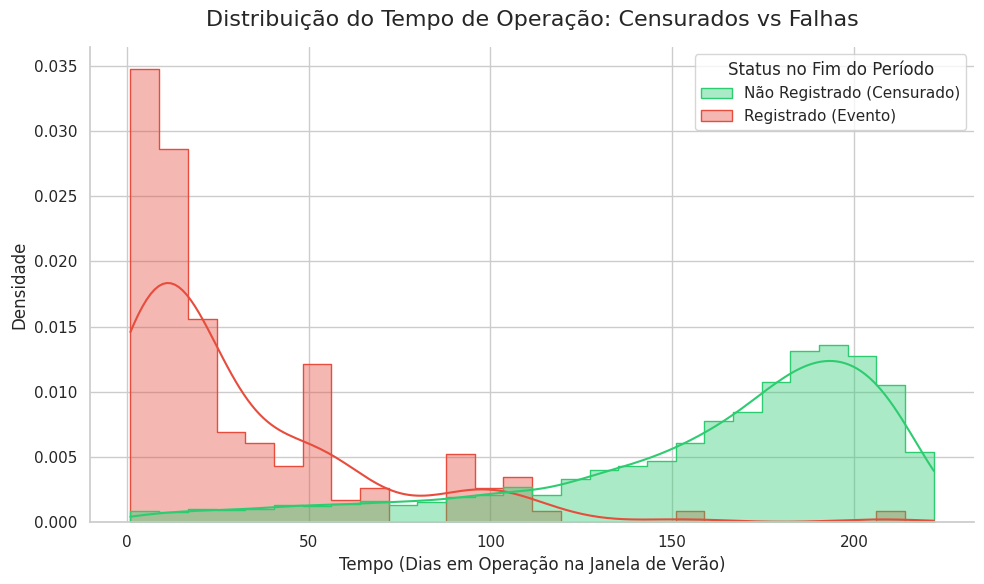

In [197]:
def plot_distribuicao_tempo(df):
    plt.figure(figsize=(10, 6))

    # Criando o histograma sobreposto com linha de densidade (KDE)
    ax = sns.histplot(
        data=df,
        x='tempo',
        hue='possui_registro',
        kde=True,               # Adiciona a linha suave de tendência
        element="step",         # Estilo do preenchimento
        stat="density",         # Normaliza para podermos comparar volumes diferentes
        common_norm=False,      # Calcula a densidade independente para True e False
        palette=['#2ecc71', '#e74c3c'],
        hue_order=[False, True],
        alpha=0.4               # Transparência para vermos a sobreposição
    )

    # Personalizando textos e legendas
    plt.title('Distribuição do Tempo de Operação: Censurados vs Falhas', fontsize=16, pad=15)
    plt.xlabel('Tempo (Dias em Operação na Janela de Verão)', fontsize=12)
    plt.ylabel('Densidade', fontsize=12)

    # Ajustando a legenda padrão do Seaborn
    legenda = ax.get_legend()
    if legenda:
        legenda.set_title("Status no Fim do Período")
        # Substitui os textos True/False por algo que a banca entenda
        for t, l in zip(legenda.texts, ['Não Registrado (Censurado)', 'Registrado (Evento)']):
            t.set_text(l)

    sns.despine()
    plt.tight_layout()
    plt.show()

plot_distribuicao_tempo(df_main)

Veículos que tiveram registro de falha no ar condicionado tendem a apresentar o evento mais cedo na janela de observação, enquanto veículos sem registro permanecem operando por períodos maiores sem ocorrência observada.

Isso pode indicar que a Operação Verão possui capacidade de detectar rapidamente veículos potencialmente problemáticos, fazendo com que permaneçam predominantemente veículos sem ocorrência observada ao longo do restante do período.

### Gráfico de barras empilhado da frequência de ônibus por idade.

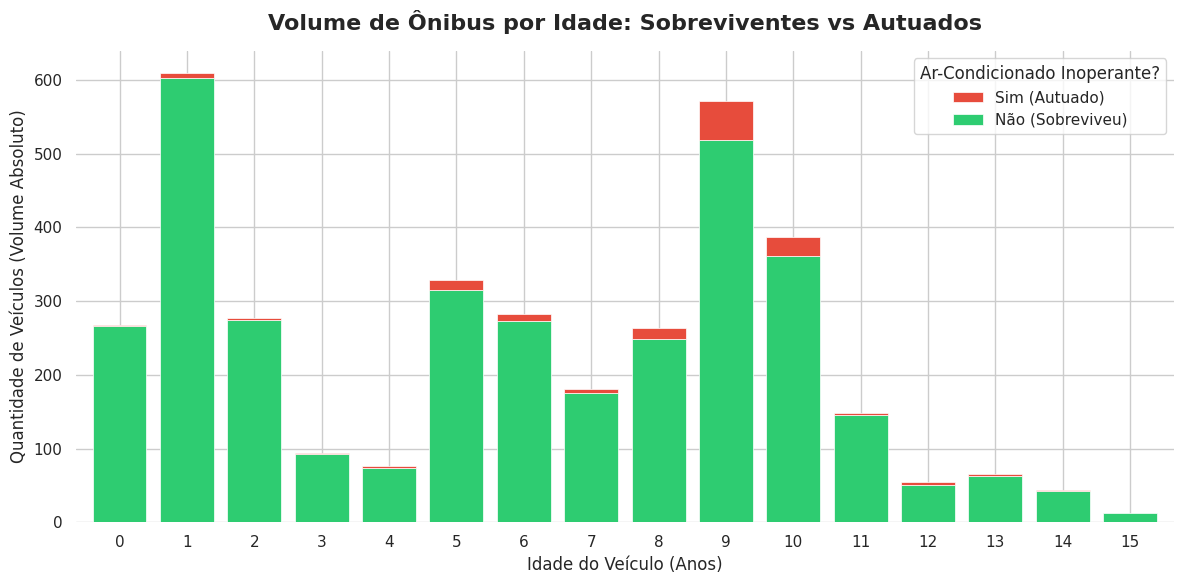

In [198]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def plot_barras_idade_empilhada(df):
    # 1. Fazemos uma cópia rápida só das colunas que vamos usar
    df_plot = df[['idade_veiculo', 'possui_registro']].copy()

    # 2. O TRUQUE DE MESTRE: Transformamos o booleano em texto explícito
    df_plot['Status'] = df_plot['possui_registro'].map({
        False: 'Não (Sobreviveu)',
        True: 'Sim (Autuado)'
    })

    # 3. Cria a tabela cruzada usando a coluna de texto nova
    ct = pd.crosstab(df_plot['idade_veiculo'], df_plot['Status'])

    # 4. Força a ordem exata para empilhar: Base Verde ('Não') embaixo, Topo Vermelho ('Sim') em cima
    ordem_desejada = ['Não (Sobreviveu)', 'Sim (Autuado)']

    # Filtra só o que realmente existe no dataframe para não dar erro
    colunas_presentes = [col for col in ordem_desejada if col in ct.columns]
    ct = ct[colunas_presentes]

    # Mapeia as cores dinamicamente garantindo que o verde fique com o Não e o vermelho com o Sim
    mapa_cores = {'Não (Sobreviveu)': '#2ecc71', 'Sim (Autuado)': '#e74c3c'}
    cores_finais = [mapa_cores[col] for col in colunas_presentes]

    # 5. Plotando! Agora 100% blindado contra bugs
    ax = ct.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6),
        color=cores_finais,
        width=0.8,
        edgecolor='white',
        linewidth=0.5
    )

    # Formatação visual
    plt.title('Volume de Ônibus por Idade: Sobreviventes vs Autuados', fontsize=16, pad=15, fontweight='bold')
    plt.xlabel('Idade do Veículo (Anos)', fontsize=12)
    plt.ylabel('Quantidade de Veículos (Volume Absoluto)', fontsize=12)
    plt.xticks(rotation=0)

    # Ajustando a legenda (invertendo para o Sim ficar visualmente em cima na legenda)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1],
        labels[::-1],
        title='Ar-Condicionado Inoperante?',
        loc='upper right'
    )

    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

# Testando agora vai rodar liso!
plot_barras_idade_empilhada(df_main)

Ônibus novos tem poucas ocorrências de registros.

### Gráfico de barras para variáveis categóricas.

In [213]:
def plot_barras_agrupadas(df, var_discreta, var_indicadora):
    """
    Gera um gráfico de barras agrupadas usando Seaborn.
    As barras são ordenadas de forma decrescente pelo volume total da variável discreta.
    """
    # 1. Define um estilo limpo para o fundo
    sns.set_theme(style="whitegrid")

    # 2. Calcula a ordem decrescente das categorias da variável discreta
    ordem_decrescente = df[var_discreta].value_counts().index

    # 3. Inicializa a figura com um tamanho bom para dashboards/telas
    plt.figure(figsize=(12, 6))

    # 4. Gera o gráfico de barras agrupadas (countplot)
    ax = sns.countplot(
        data=df,
        x=var_discreta,
        hue=var_indicadora,
        order=ordem_decrescente,
        palette="pastel" # Paleta suave para não cansar os olhos dos jurados
    )

    # 5. Formatação de títulos e eixos
    plt.title(f'Distribuição de {var_discreta} segregada por {var_indicadora}', fontsize=16, pad=15)
    plt.xlabel(var_discreta.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Frequência (Volume Absoluto)', fontsize=12)

    # Rotaciona os nomes no eixo X para evitar sobreposição (útil para nomes de consórcios ou linhas)
    plt.xticks(rotation=45, ha='right')

    # Move a legenda para fora do gráfico para não cobrir as barras
    plt.legend(title=var_indicadora.replace('_', ' ').title(), bbox_to_anchor=(1.01, 1), loc='upper left')

    # Ajusta o layout para garantir que nada fique cortado na exportação
    plt.tight_layout()

    # Exibe o gráfico
    plt.show()

variaveis_categoricas = [
    "carroceria_padronizada",
    "tecnologia",
    "tipo_veiculo"
]

#### Carroceria

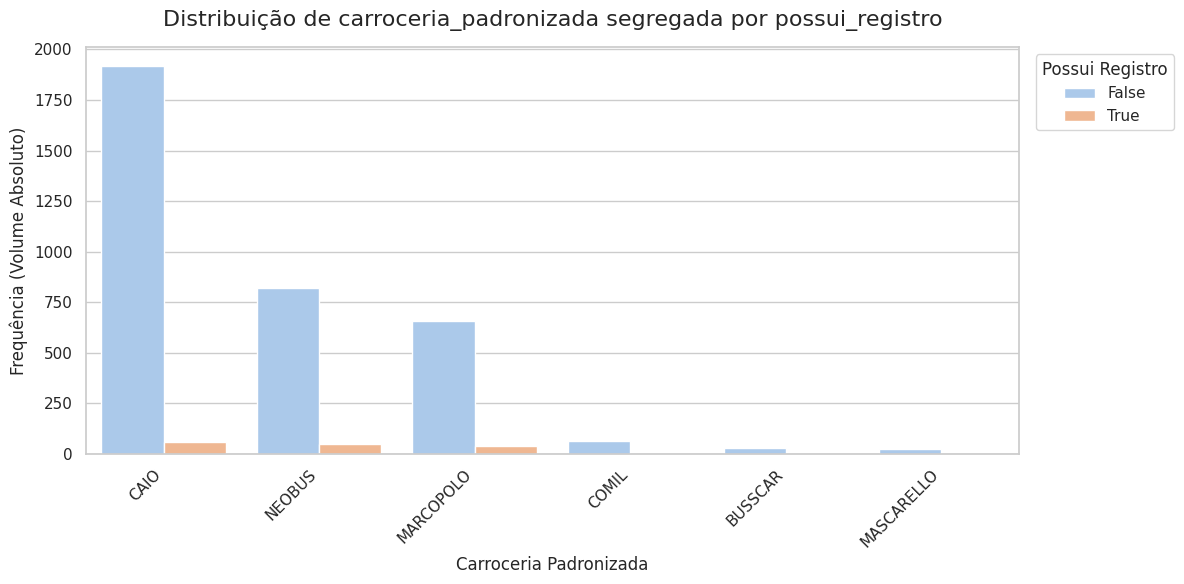

In [214]:
plot_barras_agrupadas(df_main, "carroceria_padronizada", "possui_registro")

A maior parte dos ônibus são da Caio e não parece haver diferença significativa na proporção de registros.

#### Tecnologia

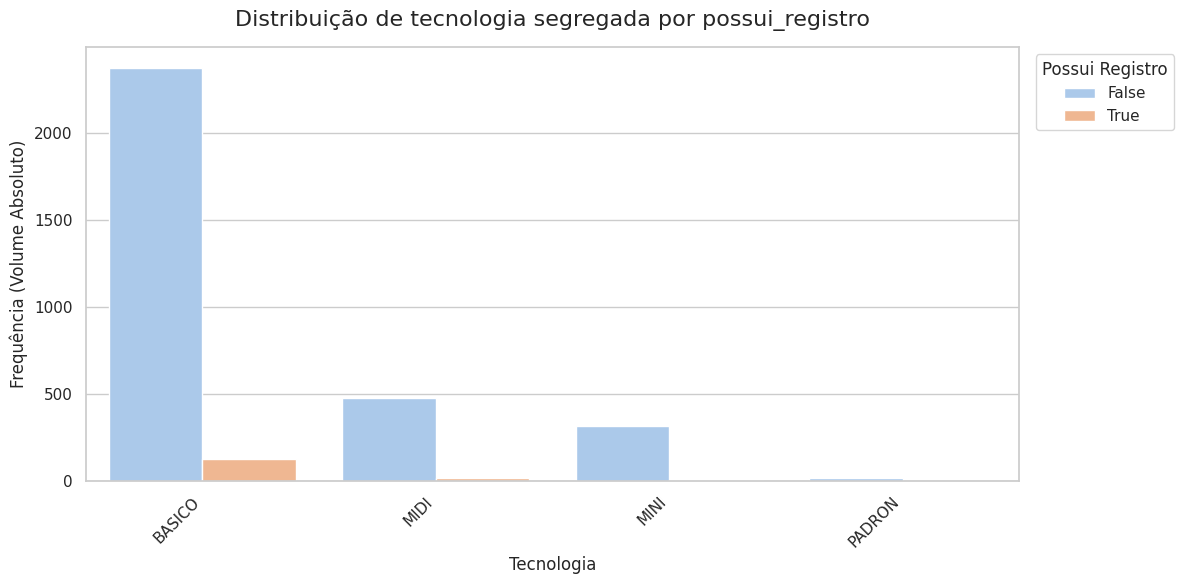

In [215]:
plot_barras_agrupadas(df_main, "tecnologia", "possui_registro")

Ônibus básicos concentram quase todos os registros.

#### Tipo Veículo

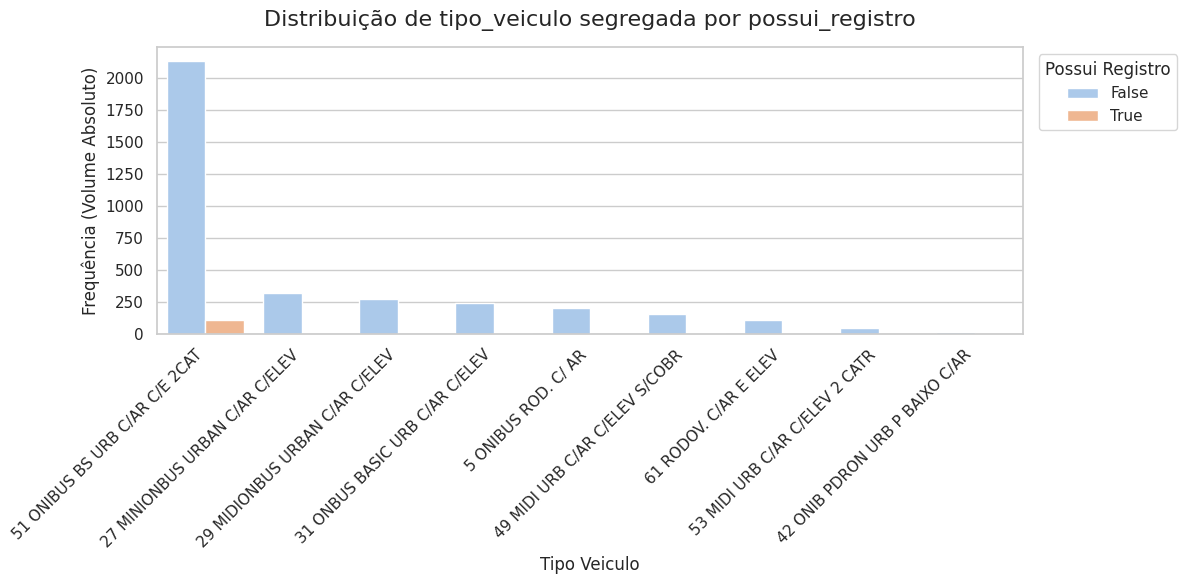

In [216]:
plot_barras_agrupadas(df_main, "tipo_veiculo", "possui_registro")

###Boxplot Lotação de Não Autuados contra Autuados

/tmp/ipykernel_22995/407306311.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


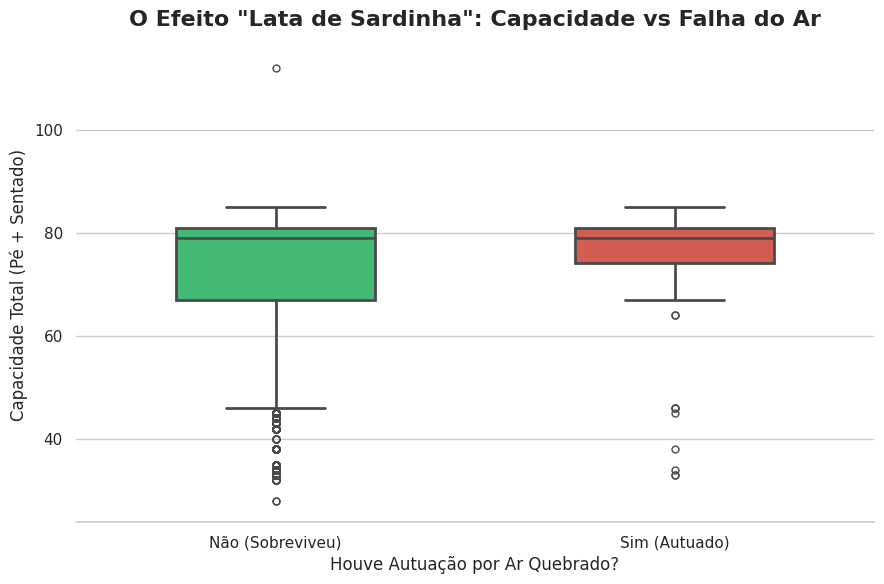

In [203]:
def plot_efeito_lotacao(df):
    plt.figure(figsize=(9, 6))

    # 1. Feature Engineering rápida: Criando a capacidade total
    df_plot = df.copy()

    # 2. Traduzindo o status para ficar bonito no eixo X
    df_plot['Status'] = df_plot['possui_registro'].map({
        False: 'Não (Sobreviveu)',
        True: 'Sim (Autuado)'
    })

    # 3. Plotando o Boxplot
    ax = sns.boxplot(
        data=df_plot,
        x='Status',
        y='lotacao_total',
        palette=['#2ecc71', '#e74c3c'], # Verde e Vermelho
        order=['Não (Sobreviveu)', 'Sim (Autuado)'],
        width=0.5,
        linewidth=2,
        fliersize=5 # Tamanho dos pontos fora da curva (outliers)
    )

    # 4. Formatação visual
    plt.title('O Efeito "Lata de Sardinha": Capacidade vs Falha do Ar', fontsize=16, pad=15, fontweight='bold')
    plt.xlabel('Houve Autuação por Ar Quebrado?', fontsize=12)
    plt.ylabel('Capacidade Total (Pé + Sentado)', fontsize=12)

    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

plot_efeito_lotacao(df_main)

O gráfico parece indicar que ônibus com pouca capacidade de lotação geralmente sobrevivem.

### Taxa Autuação por Indicadoras de Conforto

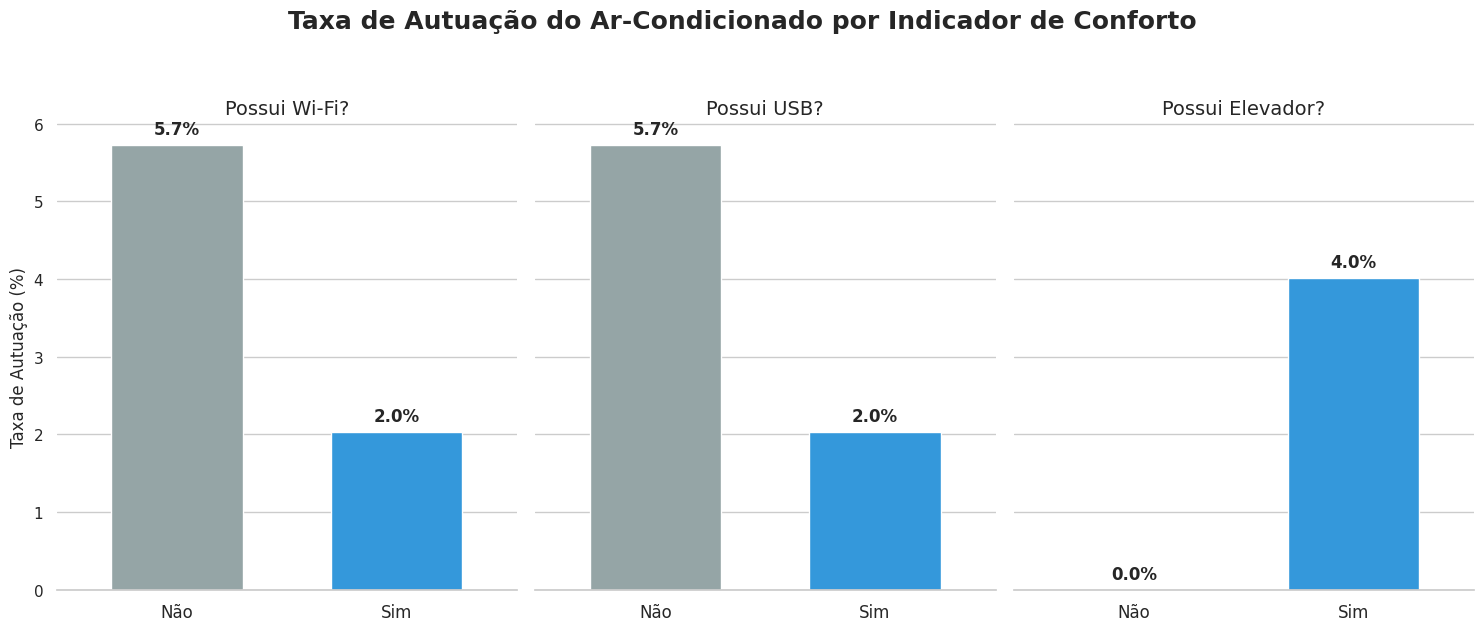

In [204]:
def plot_indicadores_conforto(df):
    # Definindo as variáveis que vamos analisar e os títulos bonitos
    indicadores = {
        'indicador_wifi': 'Possui Wi-Fi?',
        'indicador_usb': 'Possui USB?',
        'indicador_elevador': 'Possui Elevador?'
    }

    # Cria uma figura com 1 linha e 3 colunas (Painel)
    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
    fig.suptitle('Taxa de Autuação do Ar-Condicionado por Indicador de Conforto', fontsize=18, fontweight='bold', y=1.05)

    for i, (coluna, titulo) in enumerate(indicadores.items()):
        # Calcula a taxa de falha (% de True) para cada categoria (True/False do indicador)
        # Multiplica por 100 para virar porcentagem
        taxa_falha = df.groupby(coluna)['possui_registro'].mean() * 100

        # Garantindo que o índice seja formatado como Sim/Não
        taxa_falha.index = taxa_falha.index.map({False: 'Não', True: 'Sim'})

        # Plota o gráfico de barras no subplot específico (axes[i])
        ax = taxa_falha.plot(
            kind='bar',
            ax=axes[i],
            color=['#95a5a6', '#3498db'], # Cinza para "Não", Azul para "Sim"
            edgecolor='white',
            width=0.6
        )

        # Formatação de cada subplot
        axes[i].set_title(titulo, fontsize=14)
        axes[i].set_xlabel('')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0, fontsize=12)

        # Remove gridlines verticais e a linha da esquerda
        axes[i].grid(axis='x')
        axes[i].spines['left'].set_visible(False)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

        # Se for o primeiro gráfico, coloca o nome do eixo Y
        if i == 0:
            axes[i].set_ylabel('Taxa de Autuação (%)', fontsize=12)

        # Adiciona o rótulo de % em cima de cada barra
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom',
                        fontsize=12, fontweight='bold', xytext=(0, 5),
                        textcoords='offset points')

    plt.tight_layout()
    plt.show()


plot_indicadores_conforto(df_main)

Veículos com indicadores de maior conforto e modernização aparentam apresentar menores taxas de autuação relacionadas ao sistema de ar condicionado

## Modelos de Análise de Sobrevivência

### Curva Global de Sobrevivência KM

Essa curva de Análise de Sobrevivência representa a probabilidade estimada de um ônibus permanecer sem registro relacionado ao sistema de ar condicionado ao longo do tempo observado.

A função estimada é:

S(t)=P(T>t)

onde:

- T é o tempo até ocorrência do primeiro registro;
- S(t) representa a probabilidade de o veículo ainda não ter apresentado o evento até o tempo t.

Exemplo: S(100)≈0.96 indica que aproximadamente 96% dos veículos permanecem sem registro relacionado ao ar condicionado após 100 dias de observação




<Axes: xlabel='timeline'>

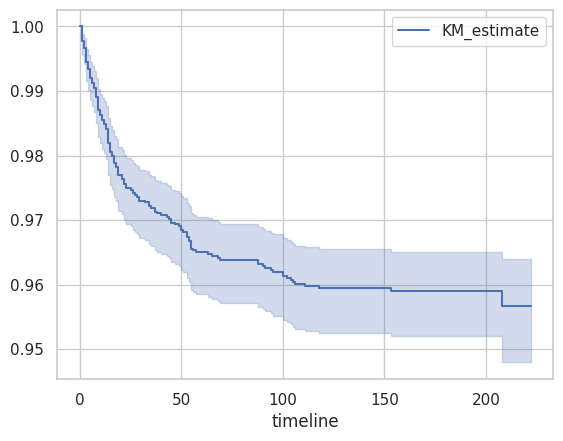

In [217]:
#!pip install lifelines
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(
    durations=df_main["tempo"],
    event_observed=df_main["possui_registro"].astype(int)
)

kmf.plot_survival_function()

A queda é bem mais acentuada no início, isso sugere que:
- Boa parte dos registros ocorre relativamente cedo
- O risco de ocorrência diminui ao longo do tempo entre os sobreviventes

### Curva de Sobrevivência por grupo

In [226]:
# Configurando um estilo elegante (padrão de publicações e dashboards)
sns.set_theme(style="whitegrid", palette="tab10")

def plotar_kaplan_meier(df, coluna_categoria, titulo):
    """
    Função reutilizável para plotar curvas de Kaplan-Meier separadas por categorias.
    """
    plt.figure(figsize=(11, 7))
    kmf = KaplanMeierFitter()

    # Remove categorias nulas para não quebrar o gráfico
    df_valido = df.dropna(subset=[coluna_categoria])

    # Descobre todas as categorias únicas na coluna
    categorias = df_valido[coluna_categoria].unique()

    for categoria in categorias:
        mask = df_valido[coluna_categoria] == categoria

        # Só plota se tiver pelo menos alguns ônibus nessa categoria (evita ruído)
        if mask.sum() > 5:
            # O .astype(int) é vital porque o lifelines espera o evento como 1 (ocorreu) ou 0 (censurado)
            kmf.fit(
                durations=df_valido.loc[mask, 'tempo'],
                event_observed=df_valido.loc[mask, 'possui_registro'].astype(int),
                label=str(categoria)
            )

            # Plotando a curva (ci_show=False tira a sombra do intervalo de confiança para ficar mais limpo)
            kmf.plot_survival_function(ci_show=False, linewidth=2.5)

    plt.title(titulo, fontsize=16, pad=15, fontweight='bold')
    plt.xlabel('Dias de Operação na Operação Verão', fontsize=12)
    plt.ylabel('Probabilidade do Ar-Condicionado NÃO Quebrar', fontsize=12)

    # Formatação do eixo Y para porcentagem (ex: 0.8 vira 80%)
    plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])

    # Ajusta a legenda
    plt.legend(title=coluna_categoria.replace('_', ' ').title(), bbox_to_anchor=(1.02, 1), loc='upper left')

    sns.despine()
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Preparação dos Dados (Criando a Faixa de Idade antes de plotar)
# ==============================================================================
# Vamos agrupar a idade contínua em blocos para a curva não virar uma bagunça
bins = [-1, 3, 8, 12, 100] # Limites das idades
labels = ['0 a 3 anos (Novos)', '4 a 7 anos (Intermediários)', '8 a 12 anos (Velhos)', '13+ anos (Guerreiros)']
df_frota_t['faixa_idade'] = pd.cut(df_frota_t['idade_veiculo'], bins=bins, labels=labels)



Parece haver diferenças no tempo até ocorrência dos registros entre os tipos de tecnologia, carroceria e faixas de idade da frota.

- mais alta a curva → menor ocorrência acumulada do evento
- mais baixa → registros ocorrem mais rapidamente.

#### Sobrevivência do Ar-Condicionado por Tecnologia (Chassi)

/tmp/ipykernel_22995/2238374483.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


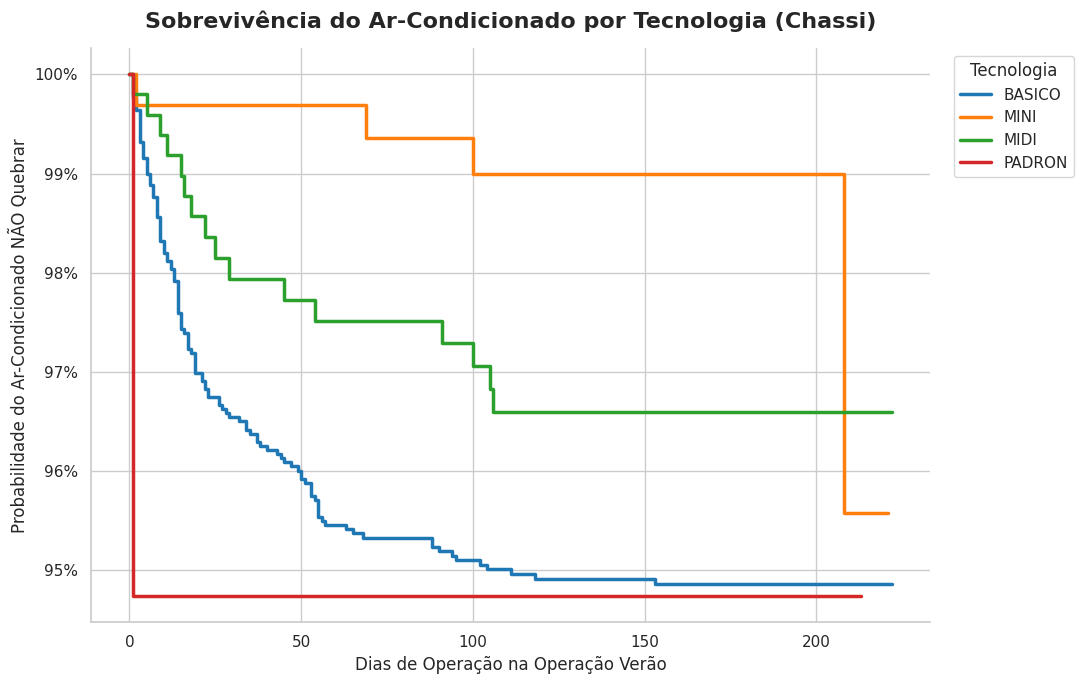

In [227]:
plotar_kaplan_meier(df_frota_t, 'tecnologia', 'Sobrevivência do Ar-Condicionado por Tecnologia (Chassi)')

#### Sobrevivência do Ar-Condicionado por Tipo de Carroceria



/tmp/ipykernel_22995/1853673836.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


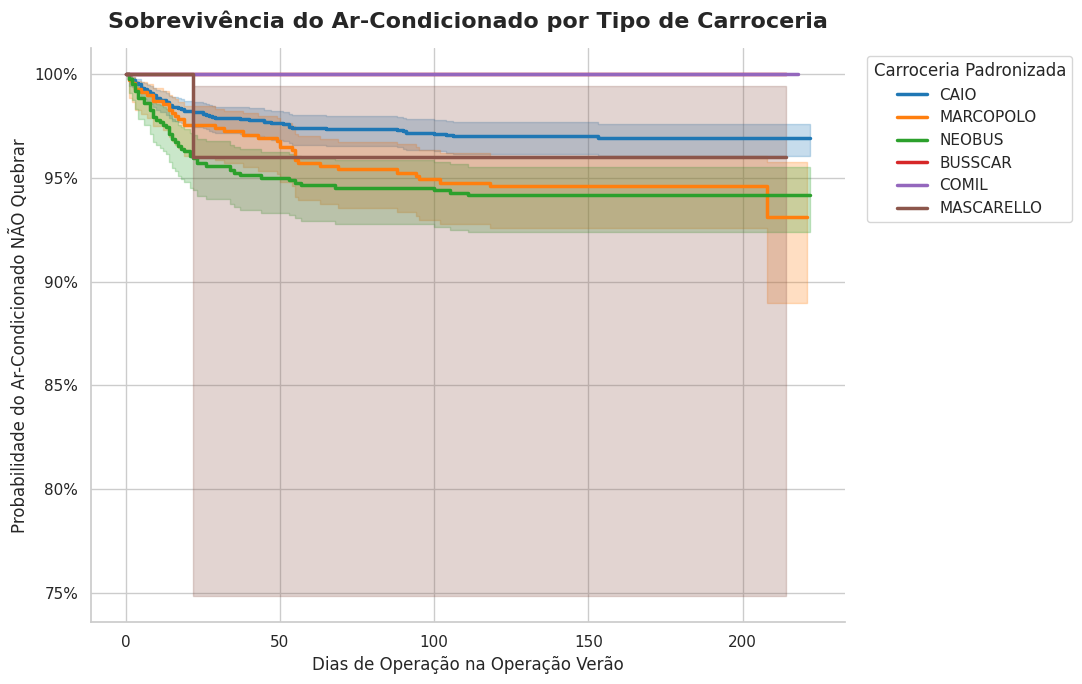

In [224]:
plotar_kaplan_meier(df_frota_t, 'carroceria_padronizada', 'Sobrevivência do Ar-Condicionado por Tipo de Carroceria')

#### O Peso do Tempo: Sobrevivência por Idade da Frota

/tmp/ipykernel_22995/1853673836.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


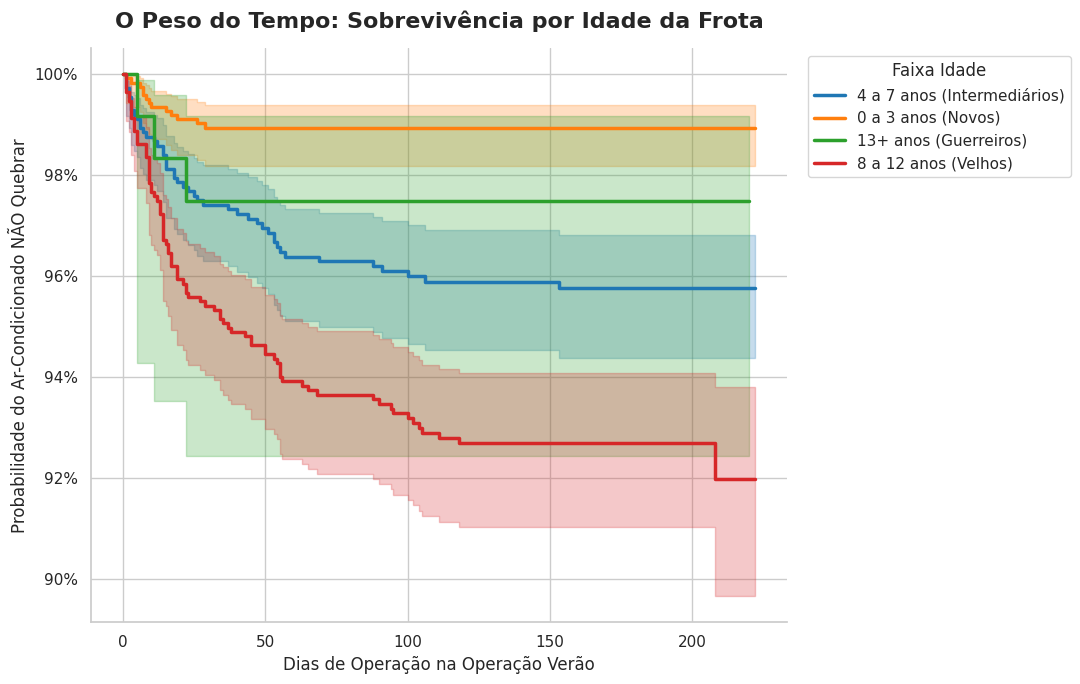

In [225]:
plotar_kaplan_meier(df_frota_t, 'faixa_idade', 'O Peso do Tempo: Sobrevivência por Idade da Frota')

### Modelo Geral KM

In [219]:
colunas_modelo = [
    'tempo', 'possui_registro', 'idade_veiculo',
    'lotacao_total', 'carroceria_padronizada'
]

# Cria um dataframe específico para o modelo, removendo possíveis nulos
df_cox = df_frota_t[colunas_modelo].dropna().copy()

# O evento precisa ser numérico (1 = Falhou, 0 = Sobreviveu)
df_cox['possui_registro'] = df_cox['possui_registro'].astype(int)

# Transformando booleanos em numéricos (1 e 0)
top = (
    df_main["carroceria_padronizada"]
    .value_counts()
    .head(1)
    .index
)

df_cox["carroceria_padronizada"] = (
    df_frota_t["carroceria_padronizada"]
    .where(
        df_frota_t["carroceria_padronizada"].isin(top),
        "OUTROS"
    )
)

# Transformando a variável categórica 'tecnologia' em Dummies (0 e 1)
# O drop_first=True é vital na estatística para evitar a "armadilha da variável dummy" (multicolinearidade)
df_cox = pd.get_dummies(df_cox, columns=['carroceria_padronizada'], drop_first=True, dtype=float)


In [221]:
print("Treinando o Modelo de Cox Proportional Hazards...")

from lifelines import CoxPHFitter
cph = CoxPHFitter()

# O comando fit recebe o dataframe, a coluna de duração (tempo) e a coluna de evento
cph.fit(df_cox, duration_col='tempo', event_col='possui_registro')

# Imprime o sumário estatístico no console
cph.print_summary()

Treinando o Modelo de Cox Proportional Hazards...


<lifelines.CoxPHFitter: fitted with 3660 total observations, 3514 right-censored observations>
             duration col = 'tempo'
                event col = 'possui_registro'
      baseline estimation = breslow
   number of observations = 3660
number of events observed = 146
   partial log-likelihood = -1153.78
         time fit was run = 2026-05-09 01:11:31 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
idade_veiculo                  0.13      1.14      0.03            0.08            0.19                1.08                1.21
lotacao_total                  0.04      1.04      0.01            0.02            0.05                1.02                1.05
carroceria_padronizada_OUTROS  0.31      1.37      0.20           -0.07            0.70                0.93                2.01

                               cmp to    z      p  -log2(p)
covariate                                                  
idade_veiculo                    0.00 4.84 <0.005     19.55
lotacao_total                    0.00 4.66 <0.005     18.26
carroceria_padronizada_OUTROS    0.00 1.61   0.11      3.21
---
Concordance = 0.69
Partial AIC = 2313.56
log-likelihood ratio test = 68.90 on 3 df
-log2(p) of ll-ratio test = 46.95

Inferências:

- Idade do Veículo: O coeficiente de 0.13 (Hazard Ratio de ~1.14) é estatisticamente significativo e intuitivo: cada ano a mais de uso aumenta em cerca de 14% o risco de registro de falha do ar-condicionado.

- Lotação Total: O impacto positivo (HR 1.04) também faz sentido físico: ônibus maiores ou mais demandados tendem a sobrecarregar o sistema de compressão.

- Veículos classificados como OUTROS (não CAIO) parecem apresentar risco instantâneo estimado aproximadamente 37% maior de ocorrência do registro quando comparados aos veículos CAIO, mas sem significância estatística.



## Conclusões

Este estudo investigou os fatores determinantes para a inoperância do sistema de climatização na frota de ônibus do Rio de Janeiro durante a Operação Verão. Através da integração de bases de licenciamento e registros operacionais, aplicou-se a análise de sobrevivência para modelar o tempo até a primeira falha registrada, tratando adequadamente a censura dos veículos que permaneceram operantes no período.

A análise exploratória revelou que os registros de falhas estão concentrados principalmente no primeiro semestre de 2024, evidenciando a sazonalidade e a pressão sobre o sistema durante os meses de maior temperatura. Os principais resultados derivados do modelo de treinamento final apontam que:

- Lotação Total: O aumento da capacidade de passageiros (lotação total) impacta positivamente o risco de falha, com um Hazard Ratio (HR) de 1.04. Isso sugere que ônibus submetidos a maior demanda de carga térmica tendem a sobrecarregar o sistema de compressão mais rapidamente.

- Fabricante da Carroceria: Veículos com carrocerias classificadas como "OUTROS" (não fabricadas pela CAIO) apresentaram um risco instantâneo estimado 37% maior de inoperância em comparação aos veículos CAIO, embora esse resultado não tenha atingido significância estatística na amostra analisada.

- Idade do Veículo: A frota analisada possui uma média de idade considerável (com registros de até 16 anos), e foi visto que cada ano a mais de uso aumenta em cerca de 14% o risco de registro de falha do ar-condicionado.

Em suma, os dados confirmam que a sobrecarga operacional, medida pela lotação, é um fator crítico para a manutenção do conforto térmico no transporte público. Estes insights servem como base para o planejamento de políticas de fiscalização e para a otimização da renovação da frota municipal, visando garantir a eficiência do serviço durante períodos críticos de calor.